# **Code-Switched Sentiment Analysis Pipeline**
## Framework: PyTorch | Model: mBART-large-50
## Transfer Learning Approaches: PEFT (LoRA) vs Full Fine-Tuning




In [ ]:
# Install necessary packages
!pip install emoji scikit-learn transformers sentencepiece torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
import emoji
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

from transformers import MBartForSequenceClassification
from transformers import MBart50TokenizerFast
from transformers import MarianMTModel, MarianTokenizer
from transformers import get_scheduler

In [ ]:
file_path = "fixed_balanced_emotion_dataset.csv"
df = pd.read_csv(file_path, encoding='latin1')
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Dataset shape: (10330, 4)
Columns: ['ï»¿Unnamed: 0', 'Tweets', 'Level 1', 'Level 2']


,ï»¿Unnamed: 0,Tweets,Level 1,Level 2
0,7706,Han ji sir wait thoda sa bhari ho gya apka,no emotion,Neutral
1,11561,please make a vedio of gwader sea khe hander e...,no emotion,Neutral
2,4377,very nice apki videos bahot achi hoti han,emotion,Happy


In [ ]:
df_clean = df.copy()

In [ ]:
# Basic Cleaning
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s:]", " ", text)  # keep emoji codes
    text = re.sub(r"\s+"," ",text).strip()
    return text.lower()

In [ ]:
# Urdu Normalization
norm_rules = {
    # 1. Phrases
    r"\b(bahut acha|bohot acha|bht acha)\b": "very good",
    r"\b(bohot ganda|bahut ganda|bht ganda)\b": "very bad",
    r"\b(bilkul nahi|bilkul nhi)\b": "not at all",
    r"\b(nahi kiya|nhi kiya)\b": "did not",
    r"\b(nahi hai|nhi hai|hai nahi)\b": "is not",
    r"\b(mat karo|mat kar)\b": "do not",
    r"\b(nahi tha|nhi tha)\b": "was not",
    r"\b(bura laga|bura lga)\b": "felt bad",

    # 2. Negations
    r"\b(nai|nhi|nahi|naa|ney|na|no)\b": "not",

    # 3. Intensifiers
    r"\b(bohot|bohat|bht|bhut|bahut)\b": "very",

    # 4. Positive Variations
    r"\b(achaa|achha|acha|achia)\b": "good",
    r"\b(khubsurat|khoobsurat|khubsorat)\b": "beautiful",
    r"\b(zabbardast|zabardast|zabrthast)\b": "amazing",
    r"\b(kamaal|kamal)\b": "amazing",
    r"\b(lajawaab|lajawab)\b": "excellent",
    r"\b(shandaar|shandar)\b": "wonderful",
    r"\b(pasand|psand)\b": "liked",
    r"\b(khushi|khush)\b": "happy",
    r"\b(mast|m मस्त)\b": "great",
    r"\b(wahh|waah|wah)\b": "wow",
    r"\b(badhiya|bdhiya)\b": "great",

    # 5. Negative Variations
    r"\b(bekar|bekaar|baykar)\b": "useless",
    r"\b(ghatya|ghatia)\b": "worst",
    r"\b(kharab|kharib|kharaab)\b": "bad",
    r"\b(bura|burra)\b": "bad",
    r"\b(ganda|gndaa)\b": "bad",
    r"\b(bewaqoof|bewakoof|bewaqof)\b": "stupid",
    r"\b(ghaleez|ghaleez)\b": "disgusting",
    r"\b(napassand|napasand)\b": "disliked",
    r"\bnagawar\b": "unpleasant",
    r"\btaklif\b": "pain",
    r"\b(dukh|dukk)\b": "sadness",
    r"\b(dard|drd)\b": "pain",
    r"\b(gussa|ghussa)\b": "angry",
    r"\b(pareshaan|preshan)\b": "troubled",
    r"\bafsos\b": "regret",
    r"\bnalayak\b": "incompetent",

    # 6. Social/Slang
    r"\b(ya|yar|yaar)\b": "yaar",
    r"\b(plz|pls|please)\b": "please",
    r"\b(thx|thanks|thnx)\b": "thanks",
    r"\bhahaha+\b": "haha",
    r"\b(haii|hay|haye)\b": "bhai",
}

def normalize_roman(text):
    for pattern,repl in norm_rules.items():
        text = re.sub(pattern,repl,text)
    return text

In [ ]:
# Reduce repetitions
def remove_repeats(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

In [ ]:
# Map emotion to sentiment
emotion_to_sentiment = {
    "Anger":0,
    "Sad":0,
    "Fear":0,
    "Disgust":0,
    "Happy":2,
    "Surprise":2,
    "Neutral":1
}

In [ ]:
df_clean["clean_text"] = df_clean["Tweets"].apply(clean_text)

df_clean["clean_text"] = df_clean["clean_text"].apply(lambda x: emoji.demojize(x))

df_clean["normalized_text"] = df_clean["clean_text"].apply(normalize_roman)

df_clean["normalized_text"] = df_clean["normalized_text"].apply(remove_repeats)

df_clean["label_id"] = df_clean["Level 2"].map(emotion_to_sentiment)
df_clean = df_clean.dropna(subset=["label_id"])

In [ ]:
# Back translation onf 5% of dataset using MarianMT
from transformers import MarianMTModel, MarianTokenizer

# English → Urdu
en2ur_model_name = "Helsinki-NLP/opus-mt-en-ur"
en2ur_tokenizer = MarianTokenizer.from_pretrained(en2ur_model_name)
en2ur_model = MarianMTModel.from_pretrained(en2ur_model_name)

# Urdu → English
ur2en_model_name = "Helsinki-NLP/opus-mt-ur-en"
ur2en_tokenizer = MarianTokenizer.from_pretrained(ur2en_model_name)
ur2en_model = MarianMTModel.from_pretrained(ur2en_model_name)

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
def back_translate(texts, batch_size=16):
    augmented_texts = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # 1. Urdu -> English
        tokens = ur2en_tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to("cuda")
        translated_ids = ur2en_model.to("cuda").generate(**tokens)
        en_texts = [ur2en_tokenizer.decode(g, skip_special_tokens=True) for g in translated_ids]

        # 2. English -> Urdu
        tokens2 = en2ur_tokenizer(en_texts, return_tensors="pt", padding=True, truncation=True).to("cuda")
        translated_ids2 = en2ur_model.to("cuda").generate(**tokens2)
        ur_texts = [en2ur_tokenizer.decode(g, skip_special_tokens=True) for g in translated_ids2]

        augmented_texts.extend(ur_texts)
        print(f"Processed {len(augmented_texts)}/{len(texts)}...")

    return augmented_texts

In [ ]:
from transformers import MBartForSequenceClassification, MBart50TokenizerFast

tokenizer = MBart50TokenizerFast.from_pretrained("facebook/mbart-large-50")
#tokenizer.src_lang = "en_XX"
tokenizer.src_lang = "hi_IN"

In [ ]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from collections import Counter

# Step 1: Split FIRST (no augmentation yet)
df_clean_filtered = df_clean[["normalized_text", "label_id"]].copy()
df_clean_filtered = df_clean_filtered.dropna(subset=["normalized_text", "label_id"])
df_clean_filtered = df_clean_filtered[df_clean_filtered["normalized_text"].str.strip().astype(bool)]
df_clean_filtered = df_clean_filtered[df_clean_filtered["label_id"].isin([0, 1, 2])]
df_clean_filtered["label_id"] = df_clean_filtered["label_id"].astype(int)

train_raw, test = train_test_split(df_clean_filtered, test_size=0.15, random_state=42, stratify=df_clean_filtered["label_id"])
train_raw, val  = train_test_split(train_raw, test_size=0.15, random_state=42, stratify=train_raw["label_id"])

# Step 2: Augment ONLY the training set
df_aug = train_raw.sample(frac=0.05, random_state=42).copy()
df_aug["normalized_text"] = back_translate(df_aug["normalized_text"].tolist())
train_raw = pd.concat([train_raw, df_aug], ignore_index=True)
print("Train after augmentation:", len(train_raw))

# Step 3: Balance the training set
target = len(train_raw[train_raw["label_id"] == 1])
train_balanced = pd.concat([
    resample(train_raw[train_raw["label_id"] == 0], replace=True, n_samples=target, random_state=42),
    train_raw[train_raw["label_id"] == 1],
    resample(train_raw[train_raw["label_id"] == 2], replace=True, n_samples=target, random_state=42),
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Train balanced:", Counter(train_balanced["label_id"]))
print("Val  (original):", Counter(val["label_id"]))
print("Test (original):", Counter(test["label_id"]))


Processed 16/373...
Processed 32/373...
Processed 48/373...
Processed 64/373...
Processed 80/373...
Processed 96/373...
Processed 112/373...
Processed 128/373...
Processed 144/373...
Processed 160/373...
Processed 176/373...
Processed 192/373...
Processed 208/373...
Processed 224/373...
Processed 240/373...
Processed 256/373...
Processed 272/373...
Processed 288/373...
Processed 304/373...
Processed 320/373...
Processed 336/373...
Processed 352/373...
Processed 368/373...
Processed 373/373...
Train after augmentation: 7836
Train balanced: Counter({0: 2273, 1: 2273, 2: 2273})
Val  (original): Counter({0: 510, 2: 424, 1: 383})
Test (original): Counter({0: 600, 2: 500, 1: 450})


In [ ]:
train_balanced.to_csv("train_processed.csv", index=False)
val.to_csv("val_processed.csv", index=False)
test.to_csv("test_processed.csv", index=False)

print("Full preprocessing + tokenization complete")

Full preprocessing + tokenization complete


In [ ]:
from torch.utils.data import Dataset
import torch

class TextDataset(Dataset):

    def __init__(self, df, tokenizer):
        self.texts = df["normalized_text"].tolist()
        self.labels = df["label_id"].tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
train_ds = TextDataset(train_balanced, tokenizer)
val_ds   = TextDataset(val, tokenizer)
test_ds  = TextDataset(test, tokenizer)

print("Sample input_ids shape:", train_ds[0]["input_ids"].shape)
print("Sample attention_mask shape:", train_ds[0]["attention_mask"].shape)
print("Sample label:", train_ds[0]["labels"])

Sample input_ids shape: torch.Size([128])
Sample attention_mask shape: torch.Size([128])
Sample label: tensor(0)


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)

In [ ]:
from collections import Counter
import torch

label_counts = Counter(train_balanced["label_id"])
print("Label distribution:", label_counts)

total = sum(label_counts.values())
class_weights = torch.tensor(
    [total / (3 * label_counts[i]) for i in range(3)],
    dtype=torch.float
).to("cuda")
print("Class weights:", class_weights)

Label distribution: Counter({0: 2273, 1: 2273, 2: 2273})
Class weights: tensor([1., 1., 1.], device='cuda:0')


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  if isinstance(logits, tuple):
    logits = logits[0]

  preds = np.argmax(logits, axis=-1)

  return {
      "accuracy": accuracy_score(labels, preds),
      "f1": f1_score(labels, preds, average="weighted")
  }


# **PEFT Fine Tuning**

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
import torch
from transformers import MBartForSequenceClassification

peft_model = MBartForSequenceClassification.from_pretrained(
    "facebook/mbart-large-50",
    num_labels=3,
    ignore_mismatched_sizes=True
)

peft_model.config.pad_token_id = tokenizer.pad_token_id
peft_model.get_input_embeddings().weight.requires_grad = True
peft_model.config.tie_word_embeddings = False

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
MBartForSequenceClassification LOAD REPORT from: facebook/mbart-large-50
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
lm_head.weight                      | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 
classif

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

peft_model = get_peft_model(peft_model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 17,334,368 || all params: 1,141,377,123 || trainable%: 1.5187


In [ ]:
import torch
from transformers import get_scheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = peft_model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.1
)

num_epochs = 6
num_training_steps = num_epochs * len(train_loader)

scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=num_training_steps
)

loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
import torch
import pandas as pd
import time
from sklearn.metrics import accuracy_score, f1_score

# Start timer
start_time = time.time()

history = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        total_train_loss += loss.item()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()

    total_val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            loss = loss_fct(
                logits.view(-1, model.config.num_labels),
                labels.view(-1)
            )

            total_val_loss += loss.item()

            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    history.append([
        epoch + 1,
        avg_train_loss,
        avg_val_loss,
        accuracy,
        f1
    ])

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f} | "
        f"Accuracy: {accuracy:.6f} | "
        f"F1: {f1:.6f}"
    )

df = pd.DataFrame(
    history,
    columns=["Epoch", "Training Loss", "Validation Loss", "Accuracy", "F1"]
)

print("\nTraining Results Table:\n")
print(df)

end_time = time.time()

print(f"\nTotal Training Time: {end_time - start_time:.2f} seconds")

Epoch 1 | Train Loss: 1.050184 | Val Loss: 0.883458 | Accuracy: 0.610478 | F1: 0.606508
Epoch 2 | Train Loss: 0.815748 | Val Loss: 0.796258 | Accuracy: 0.647684 | F1: 0.652147
Epoch 3 | Train Loss: 0.728866 | Val Loss: 0.763804 | Accuracy: 0.663629 | F1: 0.665537
Epoch 4 | Train Loss: 0.669177 | Val Loss: 0.767384 | Accuracy: 0.678815 | F1: 0.676939
Epoch 5 | Train Loss: 0.627499 | Val Loss: 0.773543 | Accuracy: 0.682612 | F1: 0.683229
Epoch 6 | Train Loss: 0.601492 | Val Loss: 0.790297 | Accuracy: 0.678056 | F1: 0.678540

Training Results Table:

   Epoch  Training Loss  Validation Loss  Accuracy        F1
0      1       1.050184         0.883458  0.610478  0.606508
1      2       0.815748         0.796258  0.647684  0.652147
2      3       0.728866         0.763804  0.663629  0.665537
3      4       0.669177         0.767384  0.678815  0.676939
4      5       0.627499         0.773543  0.682612  0.683229
5      6       0.601492         0.790297  0.678056  0.678540

Total Training Tim

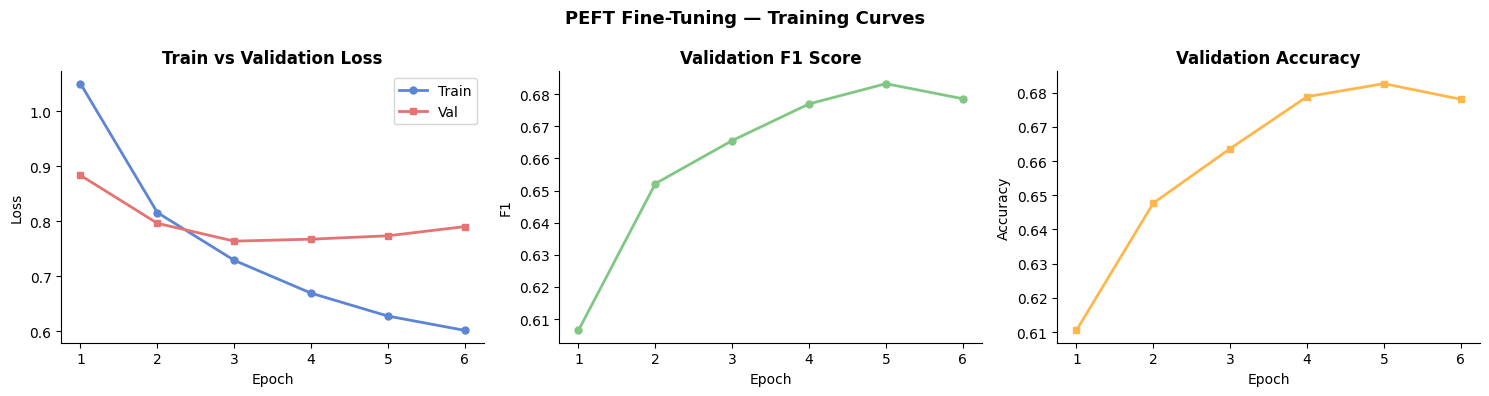

In [ ]:
# PEFT Training Curves
import matplotlib.pyplot as plt

epochs_list  = [h[0] for h in history]
train_losses = [h[1] for h in history]
val_losses   = [h[2] for h in history]
accuracies   = [h[3] for h in history]
f1_scores    = [h[4] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_list, train_losses, color='#5C85D6', linewidth=2, marker='o', markersize=5, label='Train')
axes[0].plot(epochs_list, val_losses,   color='#E57373', linewidth=2, marker='s', markersize=5, label='Val')
axes[0].set_title('Train vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].plot(epochs_list, f1_scores, color='#81C784', linewidth=2, marker='o', markersize=5)
axes[1].set_title('Validation F1 Score', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

axes[2].plot(epochs_list, accuracies, color='#FFB74D', linewidth=2, marker='s', markersize=5)
axes[2].set_title('Validation Accuracy', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

fig.suptitle('PEFT Fine-Tuning — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
import torch
import emoji

def peft_predict_sentiment(text, neutral_threshold=0.68):

    model.eval()
    device = next(model.parameters()).device

    text = clean_text(text)
    text = emoji.demojize(text)
    text = normalize_roman(text)
    text = remove_repeats(text)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    probs = torch.softmax(logits, dim=-1)[0]

    if probs[1] >= neutral_threshold:
        pred = 1
    else:
        neg_pos_probs = probs.clone()
        neg_pos_probs[1] = 0
        pred = torch.argmax(neg_pos_probs).item()

    label_map = {
        0: "Negative (Anger/Sad/Fear/Disgust)",
        1: "Neutral",
        2: "Positive (Happy/Surprise)"
    }

    print(f"Prediction : {label_map[pred]}")
    print(
        f"Confidence → Neg: {probs[0]:.3f} | "
        f"Neu: {probs[1]:.3f} | "
        f"Pos: {probs[2]:.3f}"
    )

    return label_map[pred]

In [ ]:
reviews = [
    "Bro bahut acha tha. I really enjoyed it.",
    "Maza nahi aaya.",
    "Service theek thi, kuch special nahi tha.",
    "Food bahut acha tha.",
    "Staff ka behavior bekaar tha.",
    "Price thoda zyada laga.",
    "Jagah clean thi aur environment acha tha.",
    "Quality expected se better thi.",
    "Presentation achi thi lekin taste normal tha.",
    "Value for money laga.",
    "Ambience kaafi boring tha.",
    "Experience kaafi acha raha."
]

print("PEFT Fine Tuning Sentiment Analysis")
for review in reviews:
    print("Review:", review)
    print("Predicted Sentiment:", peft_predict_sentiment(review))
    print("-" * 40)

PEFT Fine Tuning Sentiment Analysis
Review: Bro bahut acha tha. I really enjoyed it.
Prediction : Positive (Happy/Surprise)
Confidence → Neg: 0.011 | Neu: 0.030 | Pos: 0.959
Predicted Sentiment: Positive (Happy/Surprise)
----------------------------------------
Review: Maza nahi aaya.
Prediction : Neutral
Confidence → Neg: 0.139 | Neu: 0.773 | Pos: 0.088
Predicted Sentiment: Neutral
----------------------------------------
Review: Service theek thi, kuch special nahi tha.
Prediction : Neutral
Confidence → Neg: 0.064 | Neu: 0.838 | Pos: 0.098
Predicted Sentiment: Neutral
----------------------------------------
Review: Food bahut acha tha.
Prediction : Positive (Happy/Surprise)
Confidence → Neg: 0.041 | Neu: 0.060 | Pos: 0.899
Predicted Sentiment: Positive (Happy/Surprise)
----------------------------------------
Review: Staff ka behavior bekaar tha.
Prediction : Negative (Anger/Sad/Fear/Disgust)
Confidence → Neg: 0.846 | Neu: 0.115 | Pos: 0.038
Predicted Sentiment: Negative (Anger/Sad/


PEFT Fine-Tuning — Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.66      0.69       600
     Neutral       0.57      0.59      0.58       450
    Positive       0.77      0.81      0.79       500

    accuracy                           0.69      1550
   macro avg       0.68      0.69      0.69      1550
weighted avg       0.69      0.69      0.69      1550



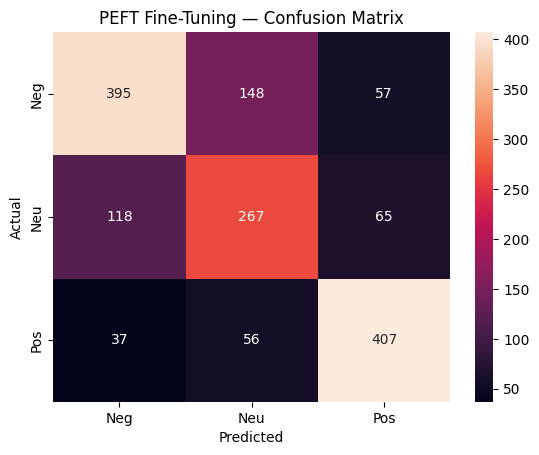

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import numpy as np

model.eval()

all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_test_labels, all_test_preds)
f1 = f1_score(all_test_labels, all_test_preds, average="weighted")

print("\nPEFT Fine-Tuning — Classification Report:")
print(classification_report(all_test_labels, all_test_preds, target_names=["Negative", "Neutral", "Positive"]))

cm = confusion_matrix(all_test_labels, all_test_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('PEFT Fine-Tuning — Confusion Matrix')
plt.show()


In [ ]:
# Save PEFT results — run this before restarting runtime
import json
from sklearn.metrics import accuracy_score, f1_score

peft_results = {
    'test_f1'        : float(f1_score(all_test_labels, all_test_preds, average='weighted')),
    'test_accuracy'  : float(accuracy_score(all_test_labels, all_test_preds)),
    'train_time_sec' : float(end_time - start_time),
}

with open('peft_results.json', 'w') as f:
    json.dump(peft_results, f)

print('PEFT results saved:', peft_results)


PEFT results saved: {'test_f1': 0.6894294229602204, 'test_accuracy': 0.6896774193548387, 'train_time_sec': 3118.432622909546}


# **Full Fine Tuning**

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
import torch
from transformers import MBartForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

full_model = MBartForSequenceClassification.from_pretrained(
    "facebook/mbart-large-50",
    num_labels=3,
    ignore_mismatched_sizes=True
)

full_model.config.pad_token_id = tokenizer.pad_token_id
full_model.get_input_embeddings().weight.requires_grad = True
full_model.config.use_cache = False
full_model.gradient_checkpointing_enable()
full_model.config.tie_word_embeddings = False

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
MBartForSequenceClassification LOAD REPORT from: facebook/mbart-large-50
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.weight                      | UNEXPECTED | 
final_logits_bias                   | UNEXPECTED | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 
classif

In [ ]:
from transformers import Adafactor

optimizer = Adafactor(
    full_model.parameters(),
    lr=1e-5,
    relative_step=False,
    scale_parameter=False,
    warmup_init=False
)

In [ ]:
import torch
from transformers import get_scheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

full_model = full_model.to(device)

num_epochs = 2
gradient_accumulation_steps = 16

num_training_steps = (num_epochs * len(train_loader)) // gradient_accumulation_steps

loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

scheduler = get_scheduler(
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)

torch.cuda.empty_cache()

In [ ]:
import time
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

start_time = time.time()

history = []

for epoch in range(num_epochs):

    full_model.train()
    total_loss = 0

    for step, batch in enumerate(train_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = full_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        loss = loss_fct(
            logits.view(-1, full_model.config.num_labels),
            labels.view(-1)
        )

        loss = loss / gradient_accumulation_steps
        loss.backward()

        if (step + 1) % gradient_accumulation_steps == 0:

            torch.nn.utils.clip_grad_norm_(full_model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    full_model.eval()

    val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = full_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            loss = loss_fct(
                logits.view(-1, full_model.config.num_labels),
                labels.view(-1)
            )

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / len(val_loader)

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    history.append([
        epoch + 1,
        train_loss,
        val_loss,
        accuracy,
        f1
    ])

df = pd.DataFrame(
    history,
    columns=["Epoch", "Training Loss", "Validation Loss", "Accuracy", "F1"]
)

print("\nTraining Results:\n")
print(df.to_string(index=False))

end_time = time.time()

print(f"\nTotal Training Time: {end_time - start_time:.2f} seconds")


Training Results:

 Epoch  Training Loss  Validation Loss  Accuracy       F1
     1       0.061208         0.846868  0.617312 0.621230
     2       0.049492         0.801020  0.636295 0.634201

Total Training Time: 1613.05 seconds


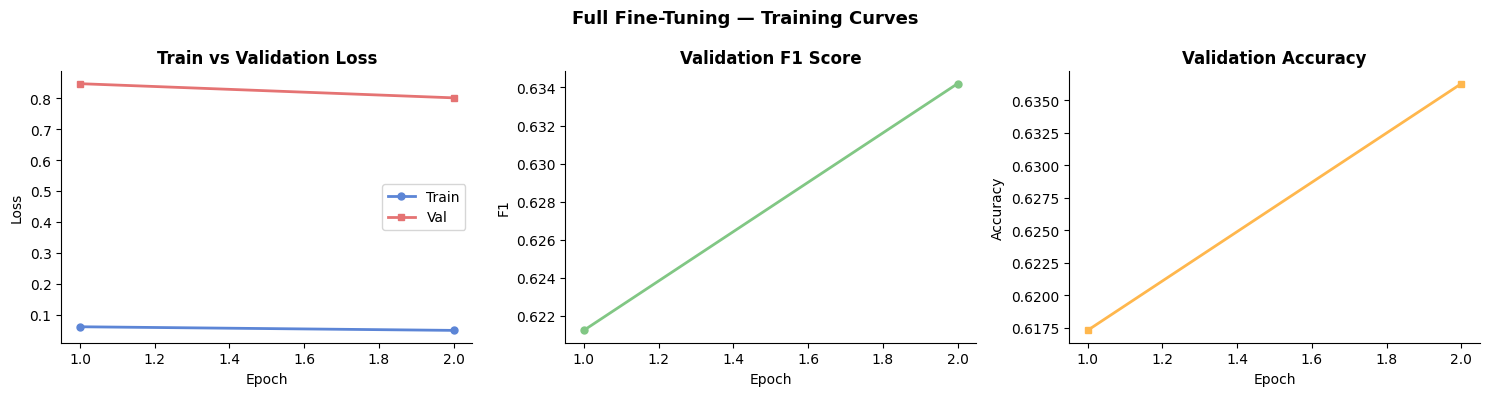

In [ ]:
# Full Fine-Tuning Training Curves
import matplotlib.pyplot as plt

epochs_list  = [h[0] for h in history]
train_losses = [h[1] for h in history]
val_losses   = [h[2] for h in history]
accuracies   = [h[3] for h in history]
f1_scores    = [h[4] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_list, train_losses, color='#5C85D6', linewidth=2, marker='o', markersize=5, label='Train')
axes[0].plot(epochs_list, val_losses,   color='#E57373', linewidth=2, marker='s', markersize=5, label='Val')
axes[0].set_title('Train vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].plot(epochs_list, f1_scores, color='#81C784', linewidth=2, marker='o', markersize=5)
axes[1].set_title('Validation F1 Score', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

axes[2].plot(epochs_list, accuracies, color='#FFB74D', linewidth=2, marker='s', markersize=5)
axes[2].set_title('Validation Accuracy', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

fig.suptitle('Full Fine-Tuning — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
def full_predict_sentiment(text, neutral_threshold=0.50):

    full_model.eval()
    device = next(full_model.parameters()).device

    text = clean_text(text)
    text = emoji.demojize(text)
    text = normalize_roman(text)
    text = remove_repeats(text)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = full_model(**inputs)
        logits = outputs.logits

    probs = torch.softmax(logits, dim=-1)[0]

    if probs[1] >= neutral_threshold:
        pred = 1
    else:
        neg_pos_probs = probs.clone()
        neg_pos_probs[1] = 0
        pred = torch.argmax(neg_pos_probs).item()

    label_map = {
        0: "Negative (Anger/Sad/Fear/Disgust)",
        1: "Neutral",
        2: "Positive (Happy/Surprise)"
    }

    print(f"Prediction : {label_map[pred]}")
    print(
        f"Confidence → Neg: {probs[0]:.3f} | "
        f"Neu: {probs[1]:.3f} | "
        f"Pos: {probs[2]:.3f}"
    )

    return label_map[pred]

In [ ]:
reviews = [
    "Bro bahut acha tha. I really enjoyed it.",
    "Maza nahi aaya.",
    "Service theek thi, kuch special nahi tha.",
    "Food bahut tasty tha.",
    "Price thoda zyada laga.",
    "Jagah clean thi aur environment acha tha.",
    "Quality expected se better thi.",
    "Presentation achi thi lekin taste normal tha.",
    "Value for money laga.",
    "Ambience kaafi boring tha.",
    "Experience kaafi acha raha."
]

print("Full Fine Tuning Sentiment Analysis")

for review in reviews:
    print("Review:", review)
    print("Predicted Sentiment:", full_predict_sentiment(review))
    print("-" * 40)

Full Fine Tuning Sentiment Analysis
Review: Bro bahut acha tha. I really enjoyed it.
Prediction : Positive (Happy/Surprise)
Confidence → Neg: 0.035 | Neu: 0.037 | Pos: 0.928
Predicted Sentiment: Positive (Happy/Surprise)
----------------------------------------
Review: Maza nahi aaya.
Prediction : Neutral
Confidence → Neg: 0.232 | Neu: 0.509 | Pos: 0.259
Predicted Sentiment: Neutral
----------------------------------------
Review: Service theek thi, kuch special nahi tha.
Prediction : Neutral
Confidence → Neg: 0.068 | Neu: 0.659 | Pos: 0.273
Predicted Sentiment: Neutral
----------------------------------------
Review: Food bahut tasty tha.
Prediction : Positive (Happy/Surprise)
Confidence → Neg: 0.147 | Neu: 0.155 | Pos: 0.698
Predicted Sentiment: Positive (Happy/Surprise)
----------------------------------------
Review: Price thoda zyada laga.
Prediction : Neutral
Confidence → Neg: 0.135 | Neu: 0.759 | Pos: 0.106
Predicted Sentiment: Neutral
----------------------------------------
Re


Full Fine-Tuning — Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.61      0.65       600
     Neutral       0.56      0.51      0.53       450
    Positive       0.66      0.79      0.72       500

    accuracy                           0.64      1550
   macro avg       0.63      0.64      0.63      1550
weighted avg       0.64      0.64      0.64      1550



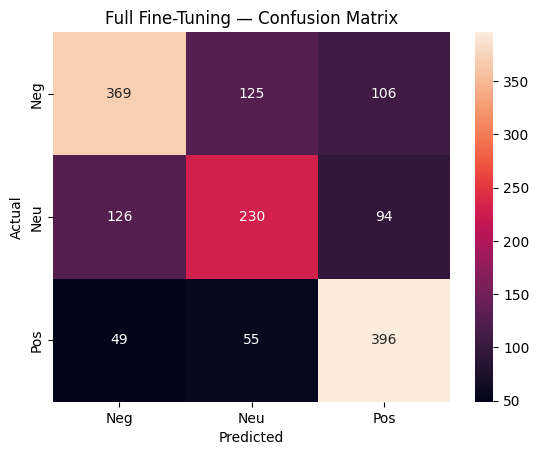

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import numpy as np

full_model.eval()

all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = full_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_test_labels, all_test_preds)
f1 = f1_score(all_test_labels, all_test_preds, average="weighted")

print("\nFull Fine-Tuning — Classification Report:")
print(classification_report(all_test_labels, all_test_preds, target_names=["Negative", "Neutral", "Positive"]))

cm = confusion_matrix(all_test_labels, all_test_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Neg','Neu','Pos'], yticklabels=['Neg','Neu','Pos'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Full Fine-Tuning — Confusion Matrix")
plt.show()


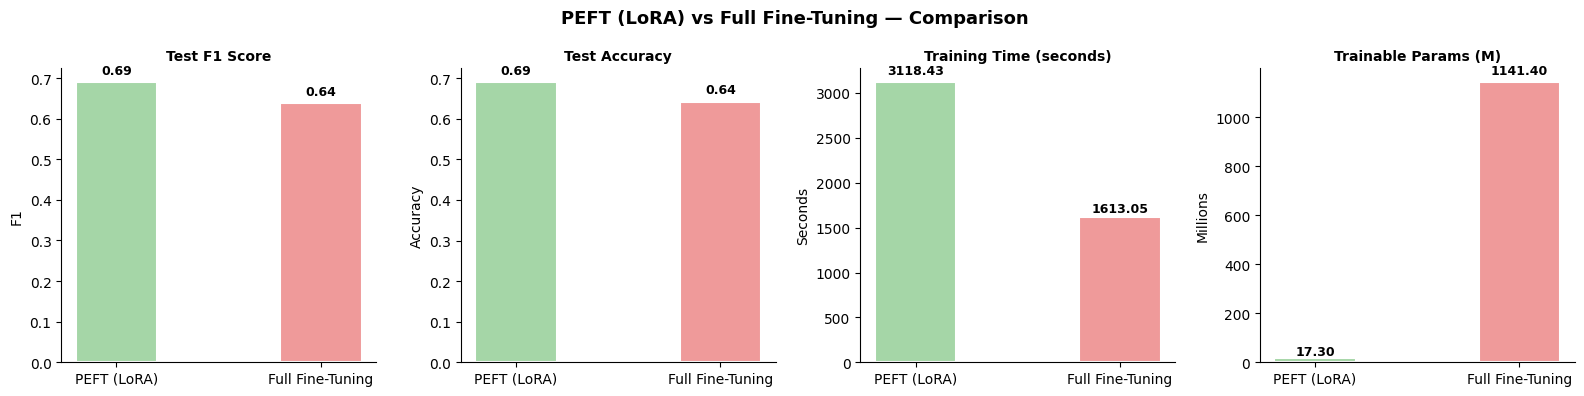

In [ ]:
# PEFT vs Full Fine-Tuning — Final Comparison
import matplotlib.pyplot as plt
import json
from sklearn.metrics import accuracy_score, f1_score

with open('peft_results.json', 'r') as f:
    peft_results = json.load(f)

full_f1   = float(f1_score(all_test_labels, all_test_preds, average='weighted'))
full_acc  = float(accuracy_score(all_test_labels, all_test_preds))
full_time = float(end_time - start_time)

# peft_model.print_trainable_parameters()
peft_param_millions = 17.3
full_param_millions = 1141.4

methods = ['PEFT (LoRA)', 'Full Fine-Tuning']
metrics = [
    ([peft_results['test_f1'],        full_f1],   'Test F1 Score',           'F1'),
    ([peft_results['test_accuracy'],  full_acc],  'Test Accuracy',           'Accuracy'),
    ([peft_results['train_time_sec'], full_time], 'Training Time (seconds)', 'Seconds'),
    ([peft_param_millions, full_param_millions],  'Trainable Params (M)',    'Millions'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#A5D6A7', '#EF9A9A']

for ax, (vals, title, ylabel) in zip(axes, metrics):
    bars = ax.bar(methods, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.4)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val:.2f}' if isinstance(val, float) else str(val),
            ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('PEFT (LoRA) vs Full Fine-Tuning — Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
